In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pint
from simulation import SimulationConfig, FieldsCalculator

from fields import gaussian_beam
ureg = pint.UnitRegistry()
pi = np.pi

/home/uspensky/PyProjects/Mie_SPP_Force/.venv/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [3]:
nx, nz = 200, 200
wl = 640e-9
xmesh = np.linspace(-2*wl, 2*wl, nx)
zmesh = np.linspace(-2*wl, 2*wl, nz)

normE = np.zeros((nz, nx))
normH = np.zeros((nz, nx))

for i in range(nx):
    for j in range(nz):
        x = xmesh[i]
        z = zmesh[j]
        E = gaussian_beam(wl=640e-9, alpha=0, amplitude=1, eps_interp='Air', point=(x,0,z), w0=450e-9, z_beam=wl)[0]
        normE[j, i] = np.sqrt(np.abs(E[0])**2 + np.abs(E[1])**2 + np.abs(E[2])**2)


for i in range(nx):
    for j in range(nz):
        x = xmesh[i]
        z = zmesh[j]
        H = gaussian_beam(wl=640e-9, alpha=0, amplitude=1, eps_interp='Air', point=(x,0,z), w0=450e-9, z_beam=wl)[1]
        normH[j, i] = np.sqrt(np.abs(H[0])**2 + np.abs(H[1])**2 + np.abs(H[2])**2)

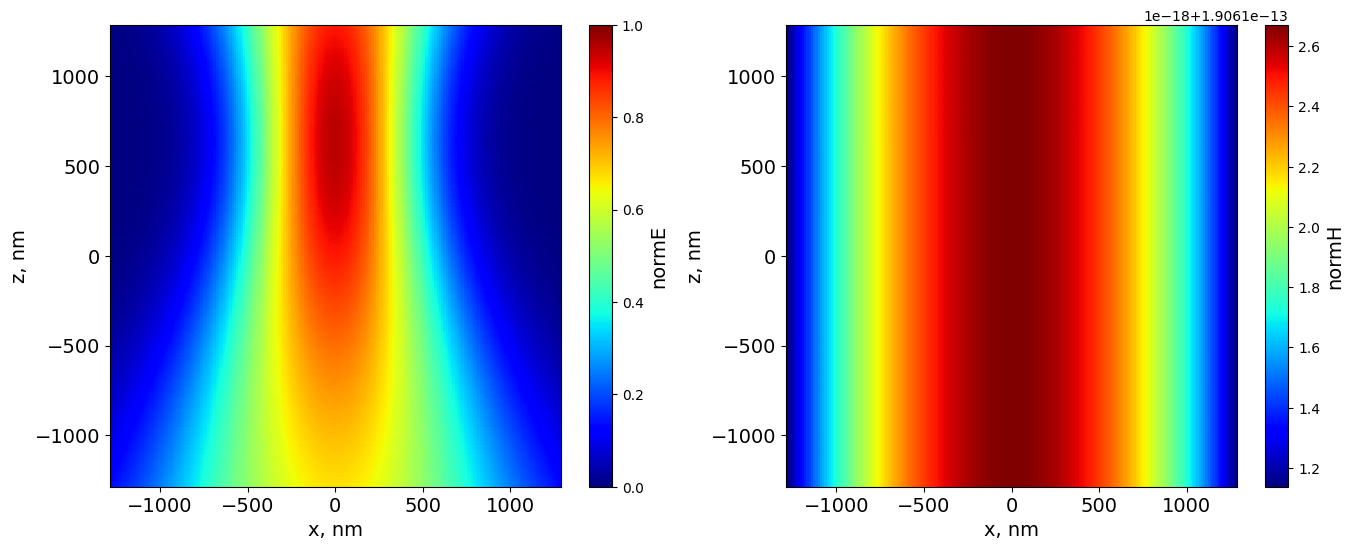

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
cmesh1 = ax1.pcolormesh(1e9*xmesh, 1e9*zmesh, normE, vmin=0, vmax=1, cmap='jet')
cbar1 = plt.colorbar(cmesh1, ax=ax1)
cbar1.set_label('normE', fontsize=14)
ax1.set_xlabel('x, nm', fontsize=14)
ax1.set_ylabel('z, nm', fontsize=14)
ax1.tick_params(axis='both', labelsize=14)

cmesh2 = ax2.pcolormesh(1e9*xmesh, 1e9*zmesh, normH, cmap='jet')
cbar2 = plt.colorbar(cmesh2, ax=ax2)
cbar2.set_label('normH', fontsize=14)
ax2.set_xlabel('x, nm', fontsize=14)
ax2.set_ylabel('z, nm', fontsize=14)
ax2.tick_params(axis='both', labelsize=14)

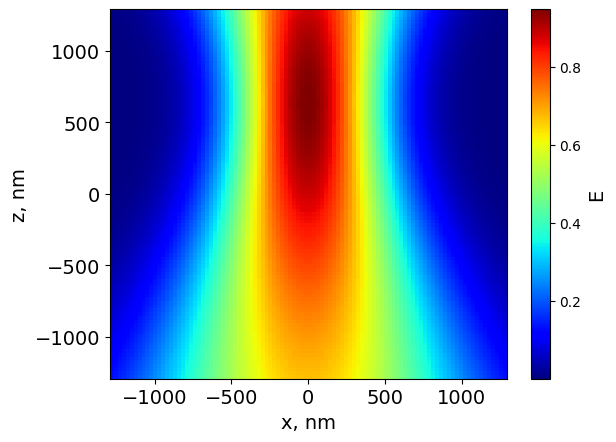

In [2]:
nx, nz = 100, 100
wl = 640e-9
xmesh = np.linspace(-2*wl, 2*wl, nx)
zmesh = np.linspace(-2*wl, 2*wl, nz)

normE = np.zeros((nz, nx))

for i in range(nx):
    for j in range(nz):
        x = xmesh[i]
        z = zmesh[j]
        E = gaussian_beam(wl=640e-9, alpha=0, amplitude=1, eps_interp='Air', point=(x,0,z), w0=450e-9, z_beam=wl)[0]
        normE[j, i] = np.sqrt(np.abs(E[0])**2 + np.abs(E[1])**2 + np.abs(E[2])**2)

fig, ax = plt.subplots()
cmesh = ax.pcolormesh(1e9*xmesh, 1e9*zmesh, normE, cmap='jet')
cbar = plt.colorbar(cmesh, ax=ax)

cbar.set_label('E', fontsize=14)
ax.set_xlabel('x, nm', fontsize=14)
ax.set_ylabel('z, nm', fontsize=14)
ax.tick_params(axis='both', labelsize=14)